In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

f = open("chat.txt","r",encoding="utf-8")
data = f.read()
# data
pattern = r'^\[\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}:\d{2}\s[A-Z]{2}\]\s'
messages = re.split(pattern,data,flags= re.MULTILINE)[1:]
dates = re.findall(pattern,data,flags= re.MULTILINE)
clean_dates = [date.strip().strip("[]") for date in dates ]
df = pd.DataFrame({"date" : clean_dates,"msg":messages})



In [2]:
df['date'] = pd.to_datetime(df['date'], format="%m/%d/%y, %I:%M:%S %p")
df["month"] = df["date"].dt.month_name()
df["day"] = df["date"].dt.day
df["hour"] = df["date"].dt.hour
df["year"] = df["date"].dt.year
df["name"] = df["msg"].str.extract(r"^([^:]+):")
df["msg"] = df["msg"].str.extract(r"^[^:]+:\s*(.*)")
df["name"] = df["name"].fillna("system notifications")
df[df["name"] == "system notifications"]
df["msg"] = df["msg"].str.strip("\n")

In [3]:
df[df["msg"] == "Media omitted"]

,date,msg,month,day,hour,year,name


In [4]:
from urlextract import URLExtract
url = []
extractor = URLExtract()
for message in df["msg"]:
    url.extend(extractor.find_urls(message))
print(url)

['https://www.instagram.com/reel/DT5veFsk9eg/?igsh=MW44MXpwem9vYnh3NA==', 'https://www.instagram.com/reel/DXOwQ3vDWGT/?igsh=MWcxMnB6eGd6Y256NA==']


In [5]:
df["name"].value_counts()

name
Ayaan hussain     35
Sarim             34
Wasif             29
Muhib Rehan       25
Sheraz            15
Owais Oct         13
Muhammad Bilal    12
Group x            2
M Ansaf            1
Name: count, dtype: int64

In [6]:
round((df["name"].value_counts()/df.shape[0])* 100,2).reset_index().rename(columns={"index":"name","count":"percent"})

,name,percent
0,Ayaan hussain,21.08
1,Sarim,20.48
2,Wasif,17.47
3,Muhib Rehan,15.06
4,Sheraz,9.04
5,Owais Oct,7.83
6,Muhammad Bilal,7.23
7,Group x,1.20
8,M Ansaf,0.60


In [7]:
from collections import Counter
f = open("stop_hinglish.txt","r")
stop_words = f.read()
words = []
for msg in df["msg"]:
    for word in msg.lower():
        if word not in stop_words:
            words.extend(msg.split())
Counter(words).most_common(20)

[('ka', 184),
 ('nhi', 169),
 ('h', 149),
 ('ko', 118),
 ('or', 104),
 ('tw', 100),
 ('ha', 84),
 ('message', 77),
 ('sab', 72),
 ('\u200e<This', 69),
 ('was', 69),
 ('edited>', 69),
 ('tha', 65),
 ('bhai', 63),
 ('phr', 62),
 ('Bhai', 61),
 ('koi', 60),
 ('9', 60),
 ('waja', 60),
 ('sy', 60)]

In [8]:
df["month_num"] = df["date"].dt.month

In [12]:
timeline = df.groupby(["year","month_num","month"]).count()["msg"].reset_index()
timeline.shape

(3, 4)

In [21]:
time = []
for i in range(timeline.shape[0]):
    time.append((f"{timeline["month"][i]}-{str(timeline["year"][i])}"))

In [24]:
timeline["time"] = time
timeline
# timeline["year"].shapes

,year,month_num,month,msg,time
0,2025,12,December,2,December-2025
1,2026,4,April,19,April-2026
2,2026,5,May,145,May-2026


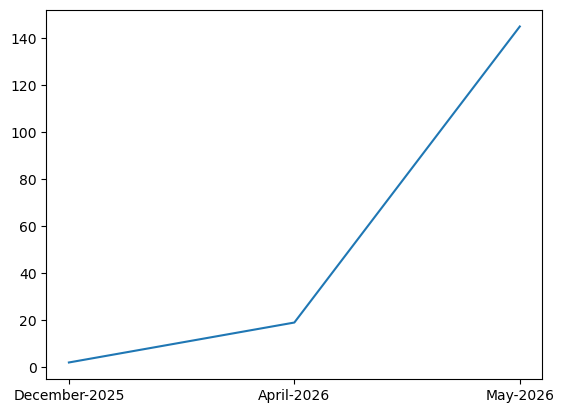

In [25]:
plt.plot(timeline["time"],timeline["msg"])

In [30]:
df["Every day"] = df["date"].dt.date
daily_timeline = df.groupby("Every day").count()["msg"].reset_index()

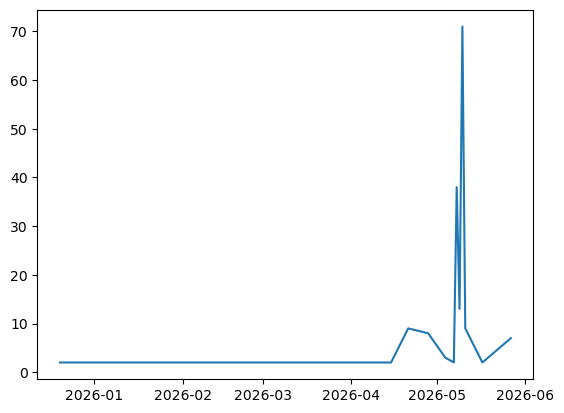

In [31]:
plt.plot(daily_timeline["Every day"],daily_timeline["msg"])

In [34]:
df["day_name"] = df["date"].dt.day_name()
df["day_name"].value_counts()

day_name
Sunday       73
Friday       38
Tuesday      17
Saturday     15
Monday       12
Wednesday     9
Thursday      2
Name: count, dtype: int64